In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel dataset
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")

# Display first 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [12]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Missing values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


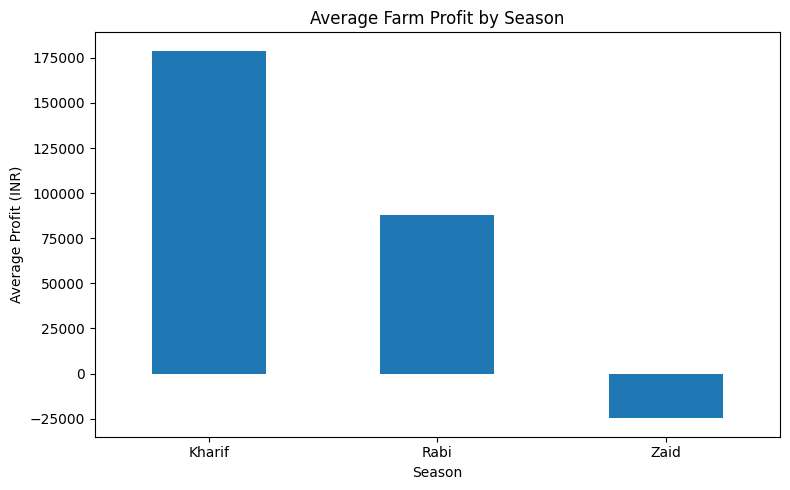

In [13]:
avg_profit = df.groupby("Season")["Profit_INR"].mean()

print(avg_profit)

plt.figure(figsize=(8,5))
avg_profit.plot(kind="bar")

plt.title("Average Farm Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Average Profit by Season:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64


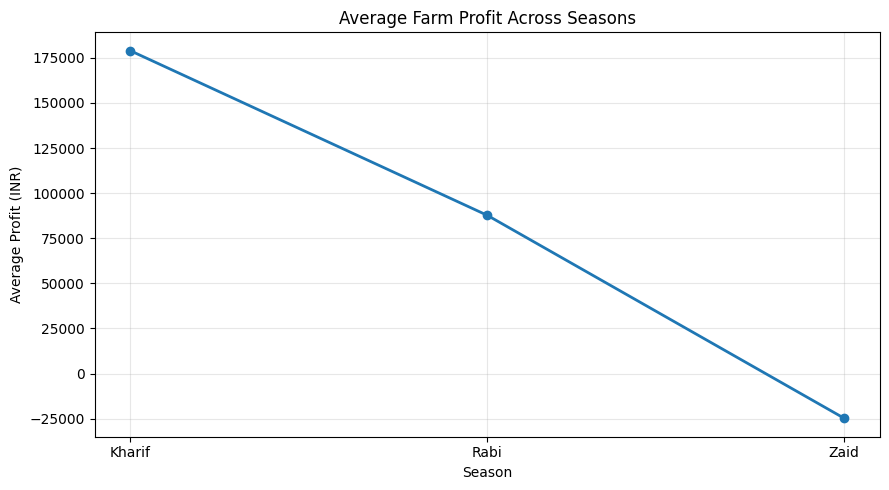

In [14]:
season_order = ["Kharif", "Rabi", "Zaid"]

avg_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .reindex(season_order)
)

print("Average Profit by Season:")
print(avg_profit.round(2))

plt.figure(figsize=(9, 5))

plt.plot(
    avg_profit.index,
    avg_profit.values,
    marker="o",
    linewidth=2
)

plt.title("Average Farm Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Crop Distribution:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


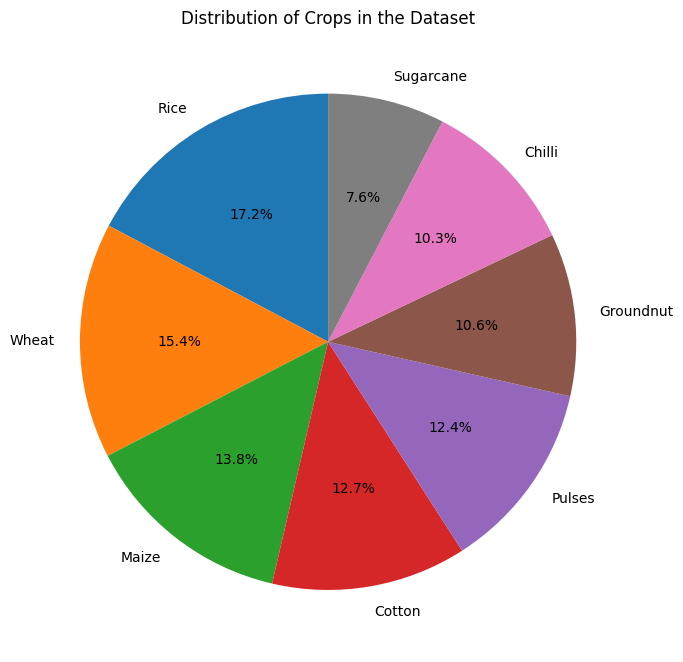

In [15]:
crop_counts = df["Crop"].value_counts()

print("Crop Distribution:")
print(crop_counts)

plt.figure(figsize=(7, 7))

plt.pie(
    crop_counts.values,
    labels=crop_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Crops in the Dataset")

plt.tight_layout()
plt.show()

Correlation between Rainfall and Yield: 0.031


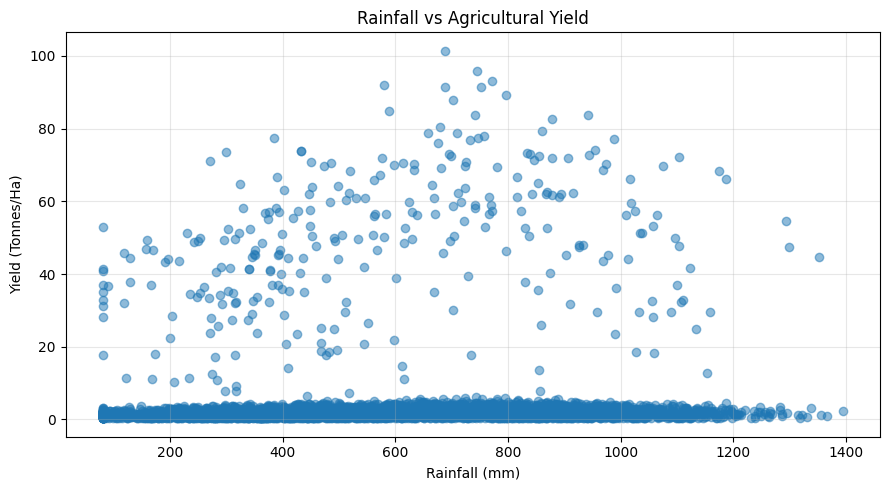

In [16]:
correlation = df["Rainfall_mm"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between Rainfall and Yield:",
      round(correlation, 3))

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Average Yield by Irrigation Method and Season:
Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                 7.26  6.21  5.85
Flood                5.00  5.10  4.03
Rainfed              5.72  3.94  3.06
Sprinkler            4.67  5.36  6.17


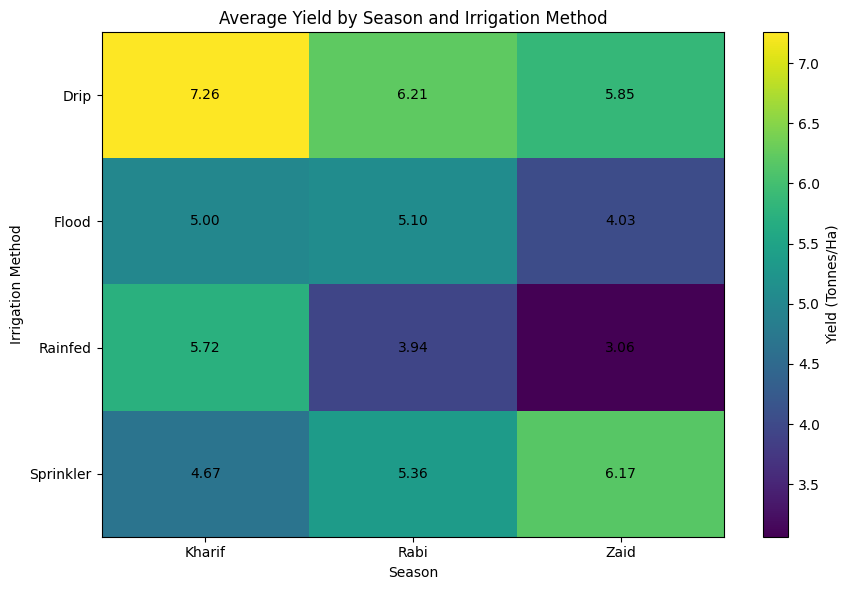

In [17]:

heatmap_data = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
)

print("Average Yield by Irrigation Method and Season:")
print(heatmap_data.round(2))

# Create heatmap
plt.figure(figsize=(9, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center",
                 va="center")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Average Yield by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.colorbar(label="Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()